In [49]:
import pandas as pd
import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier


## Load dataset

In [50]:
test_set = pd.read_csv('loan-test.csv')
train_set = pd.read_csv("loan-train.csv")

# Explanotory data analysis

In [70]:
train_set.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [51]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [71]:
train_set.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [72]:
X_train = train_set.drop("Loan_Status",axis=1)
y_train = train_set["Loan_Status"]

<Axes: xlabel='Loan_Status'>

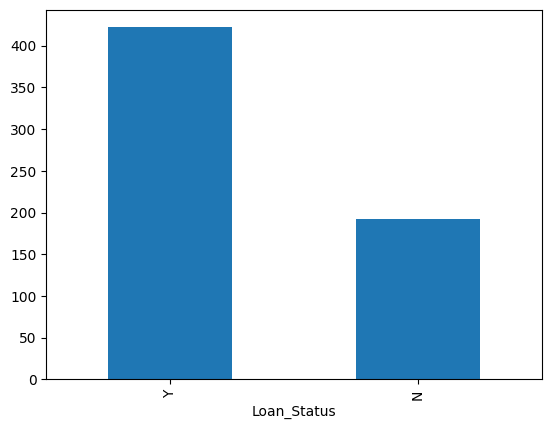

In [53]:
y_train.value_counts().plot(kind="bar")

In [54]:
corr_matrix = train_set.select_dtypes(["int","float"]).corr()

<Axes: >

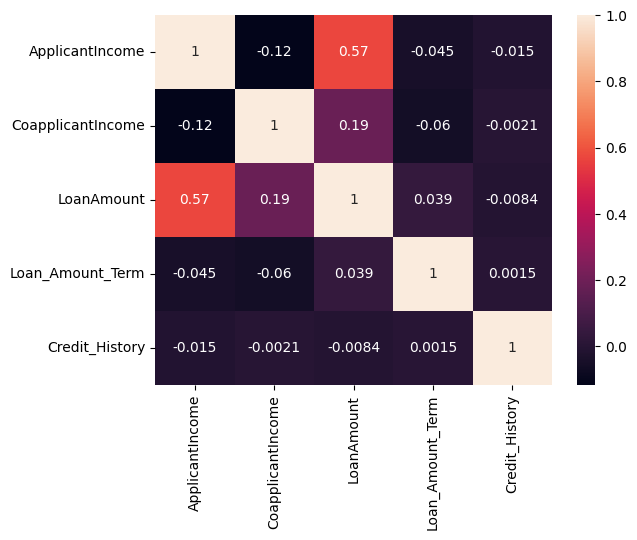

In [55]:
sb.heatmap(corr_matrix,annot=True)

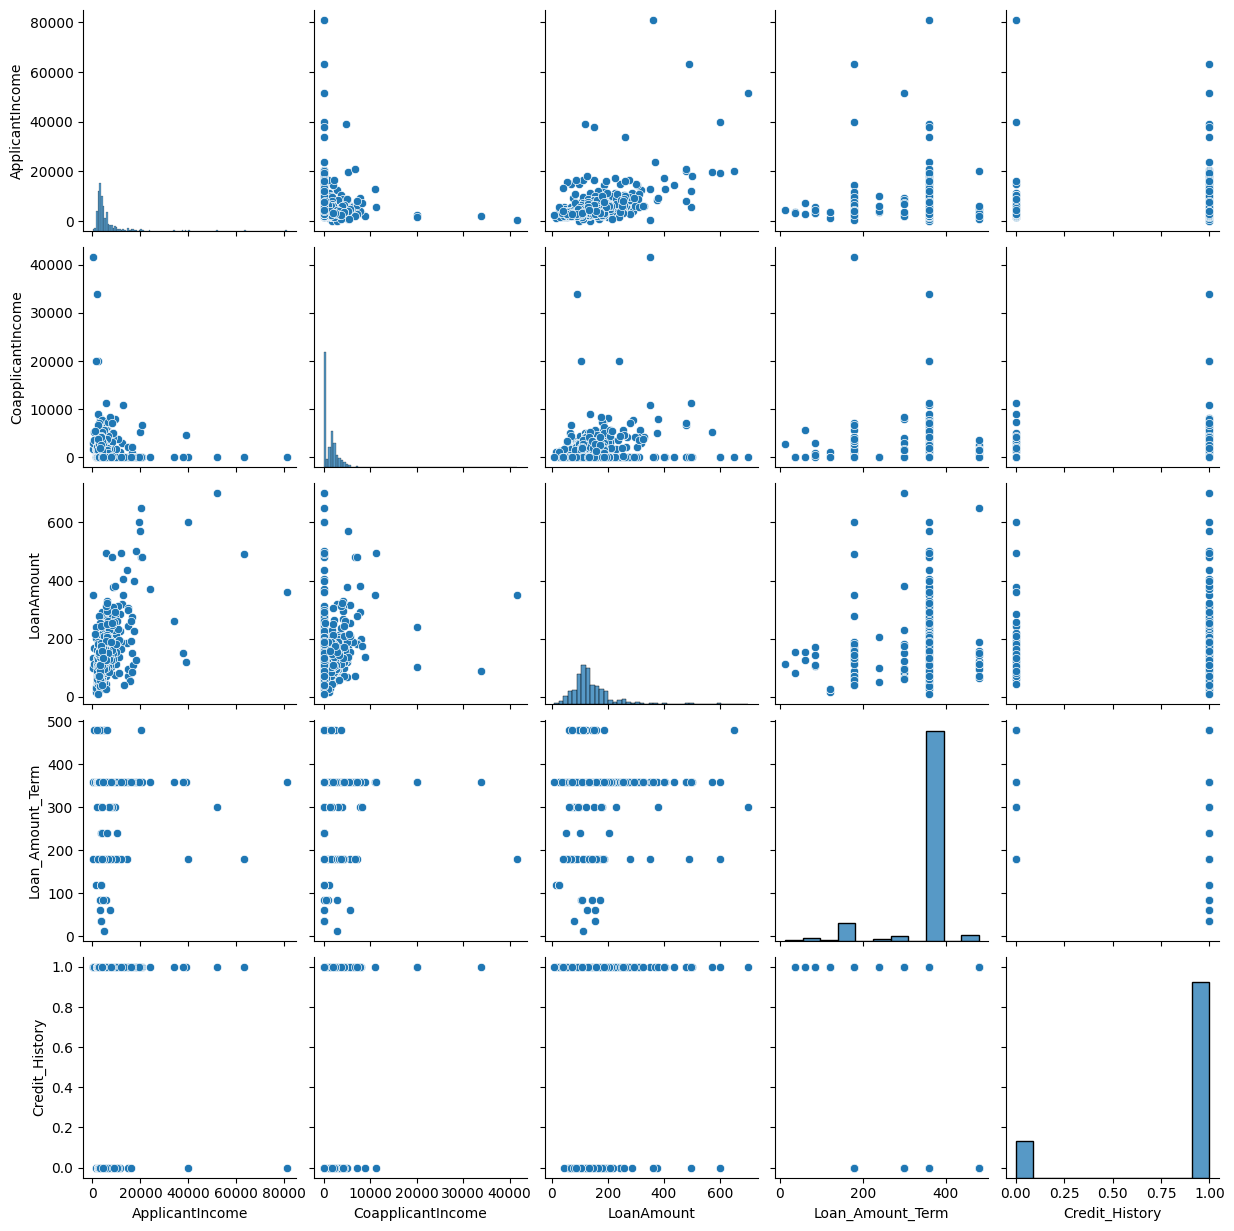

In [56]:
sb.pairplot(train_set.select_dtypes(["int","float"]))

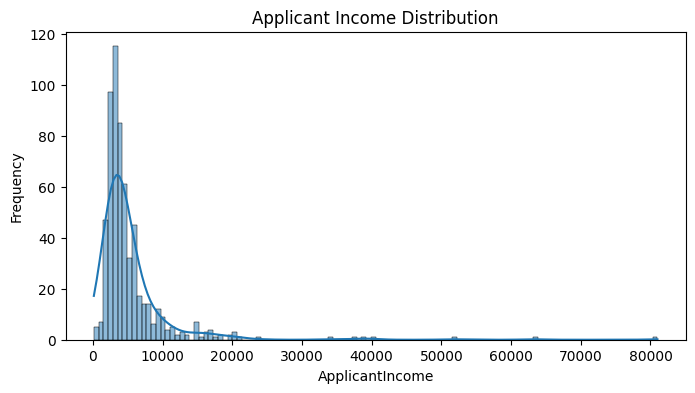

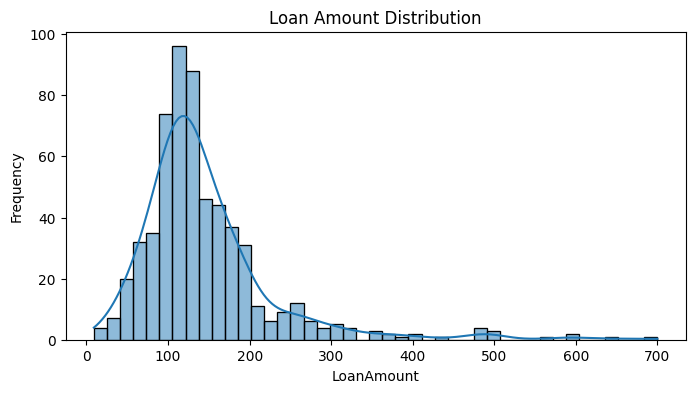

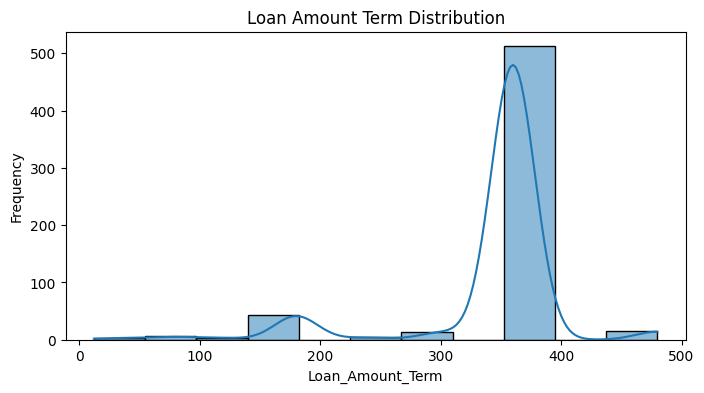

In [75]:
def plot_distribution(column, title):
    plt.figure(figsize=(8, 4))
    sb.histplot(data=train_set, x=column, kde=True)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plot_distribution("ApplicantIncome", "Applicant Income Distribution")
plot_distribution("LoanAmount", "Loan Amount Distribution")
plot_distribution("Loan_Amount_Term", "Loan Amount Term Distribution")

# Spliting X and y

In [57]:
X = train_set2.drop(["Loan_ID","Loan_Status"],axis=1)
y = train_set2["Loan_Status"]

In [58]:
y.head(10)

1     N
2     Y
3     Y
4     Y
5     Y
6     Y
7     N
8     Y
10    Y
11    Y
Name: Loan_Status, dtype: object

# Pipeline

In [59]:
# Impute and transformation 
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.1,shuffle = True)


In [60]:
col_transformation = ColumnTransformer([

    ("gender_transformation", 
     Pipeline([
        ("gen_pipeline_impute", SimpleImputer(strategy="most_frequent")),
         ("gen_pipeline_onehot",OneHotEncoder())
    ]),["Gender","Married","Dependents", "Self_Employed"]),
    
    ("education_transformation",OneHotEncoder(),["Property_Area",'Education']),
    
    ('standardscaling_transformation',StandardScaler(),["ApplicantIncome","CoapplicantIncome","LoanAmount"]),

    ('impute_standardscaler_',
     Pipeline([
         ('impute_standardscaler_impute',SimpleImputer(strategy = 'most_frequent')),
         ('impute_standardscaler_standardscaler',StandardScaler())
     ])
     ,['Loan_Amount_Term',"Credit_History"]),
])

In [61]:
X_train_transformed_data = col_transformation.fit_transform(X_train)

In [62]:
lb = LabelBinarizer()
y_train_transformed = lb.fit_transform(y_train)

In [63]:
clf = LogisticRegression(max_iter=2000,C=0.01,random_state=0).fit(X_train_transformed_data, y_train_transformed)

C:\Users\KSHITIJ\.conda\envs\tf-gpu\lib\site-packages\sklearn\utils\validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [64]:
clf.score(X_train_transformed_data, y_train_transformed)

0.821505376344086

In [65]:
X_test_transformed_data = col_transformation.fit_transform(X_test)
y_test_transformed =  lb.fit_transform(y_test)

In [66]:
clf.score(X_test_transformed_data,y_test_transformed)

0.8653846153846154

In [67]:
y_test_pred =  clf.predict(X_test_transformed_data)
print(classification_report(y_test_transformed, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67        14
           1       0.84      1.00      0.92        38

    accuracy                           0.87        52
   macro avg       0.92      0.75      0.79        52
weighted avg       0.89      0.87      0.85        52



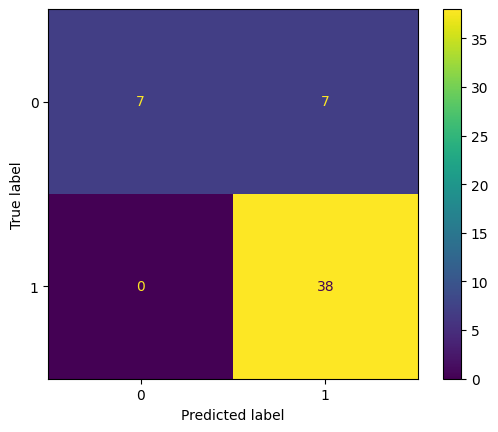

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test_transformed, y_test_pred)